In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.cluster import KMeans
 

In [2]:
df = pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.shape

(20640, 10)

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [7]:
df['median_house_value'].value_counts()

median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
           ... 
422900.0      1
349400.0      1
425800.0      1
200700.0      1
47000.0       1
Name: count, Length: 3842, dtype: int64

In [8]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [10]:
print(df.isnull().sum()), '/n', df.duplicated().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


(None, '/n', np.int64(0))

In [11]:
mean = df['total_bedrooms'].mean()
df['total_bedrooms'] = df['total_bedrooms'].fillna(mean)
 

In [12]:
unique = df['ocean_proximity'].unique()
print(unique)

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


In [13]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [14]:
columns=['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal']

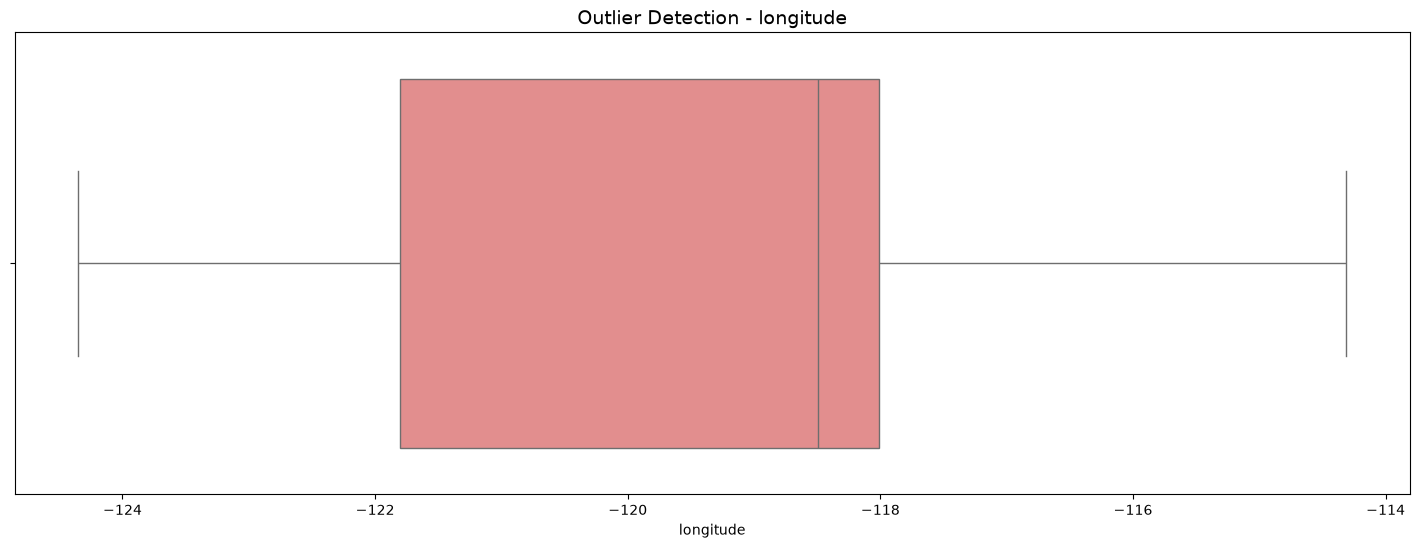

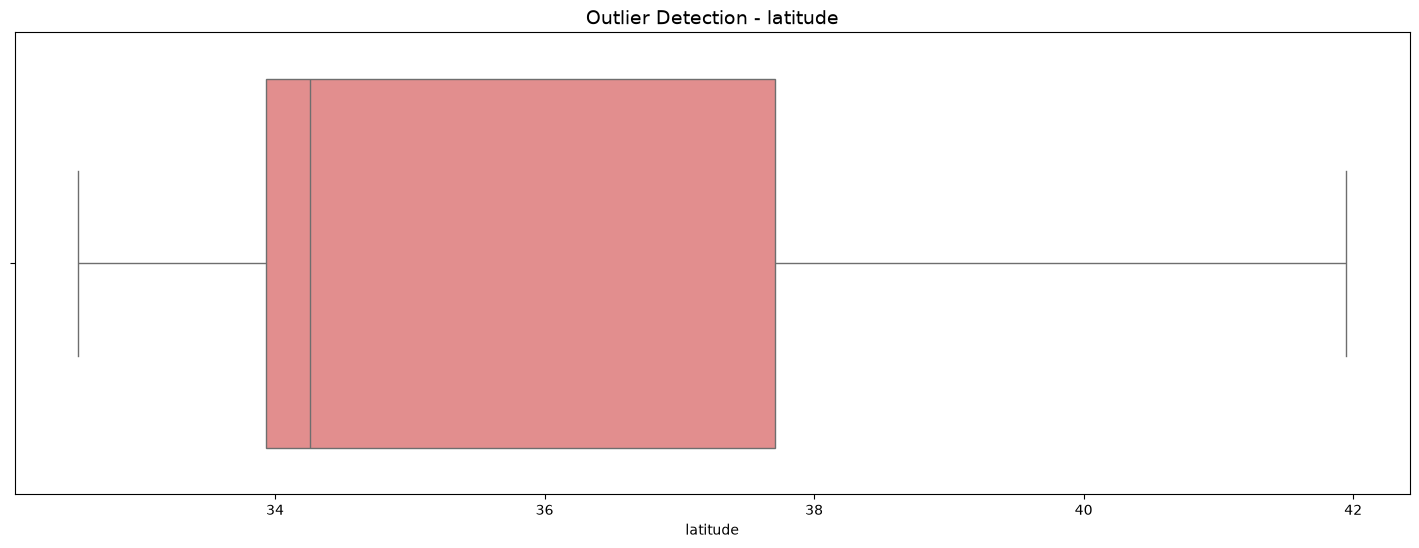

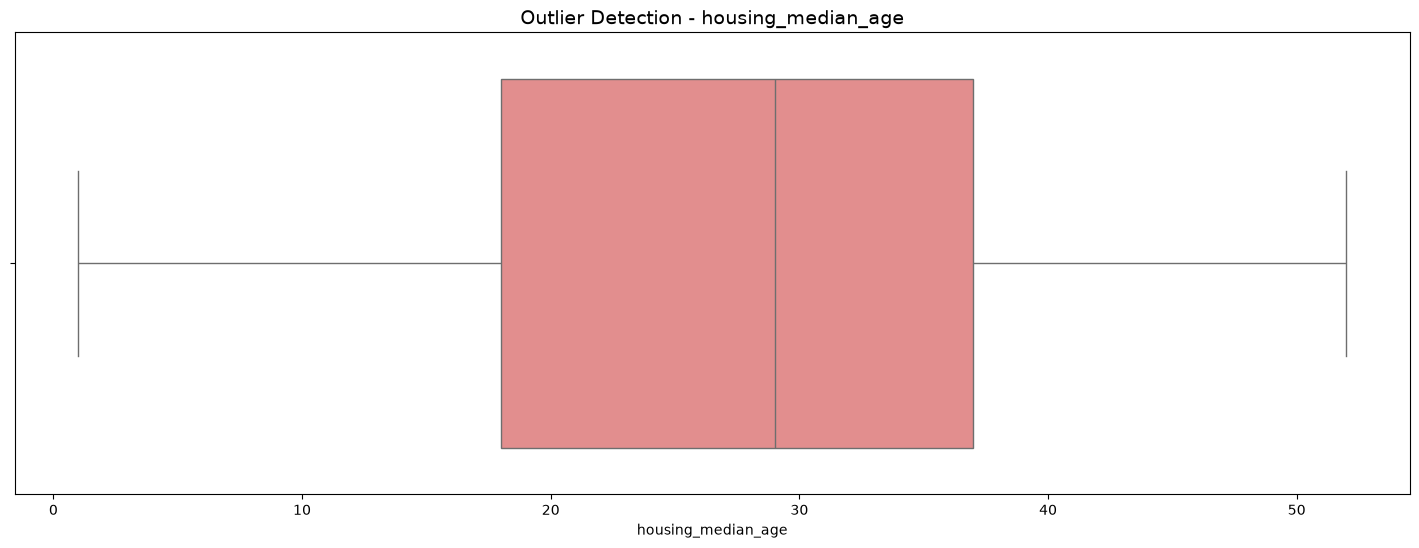

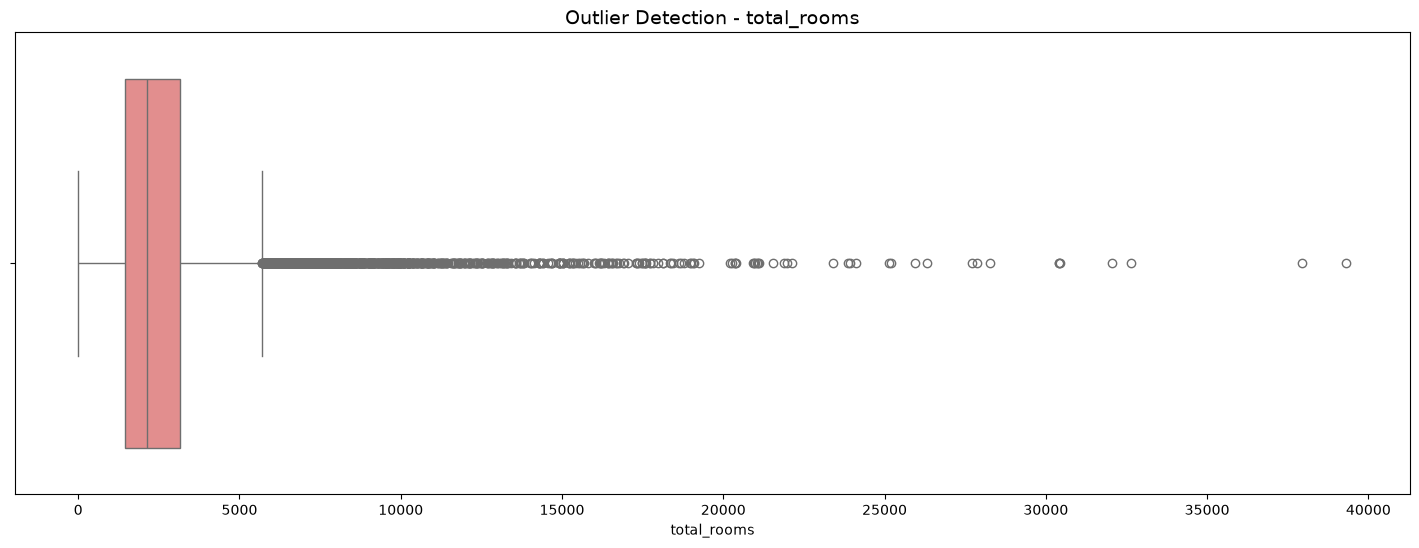

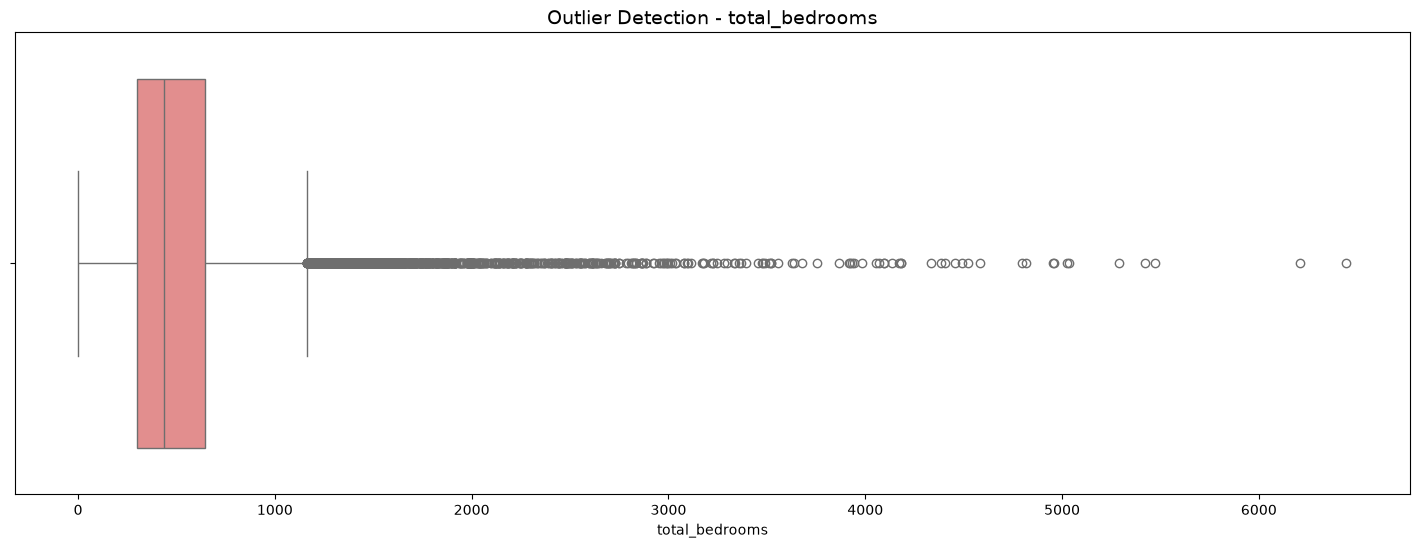

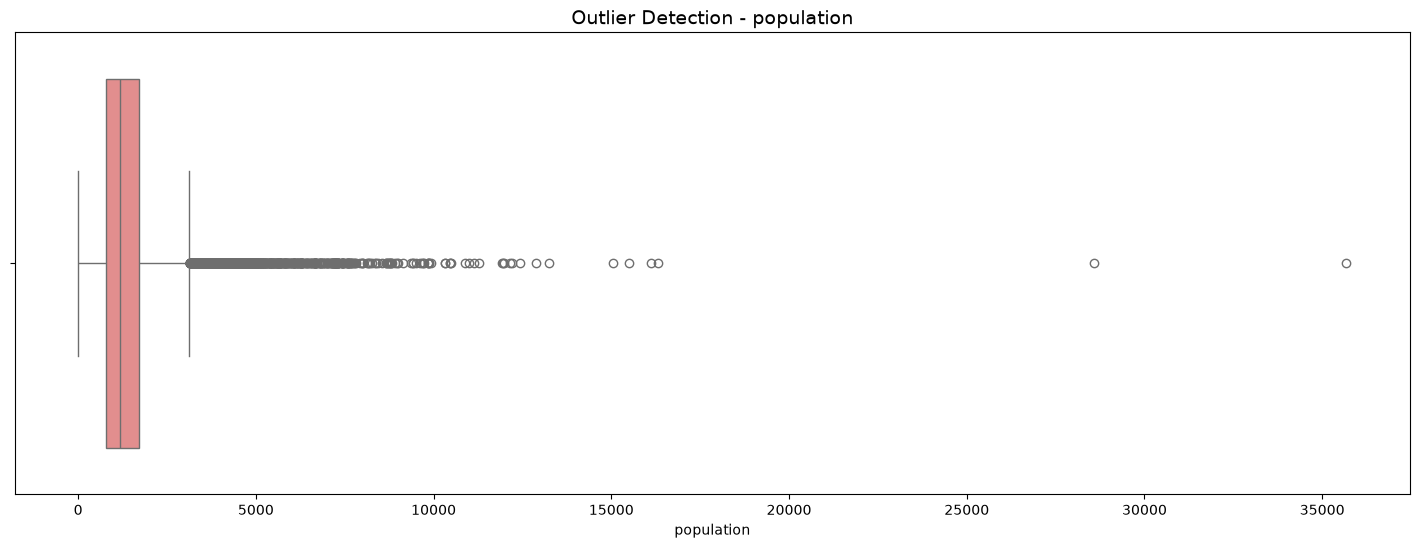

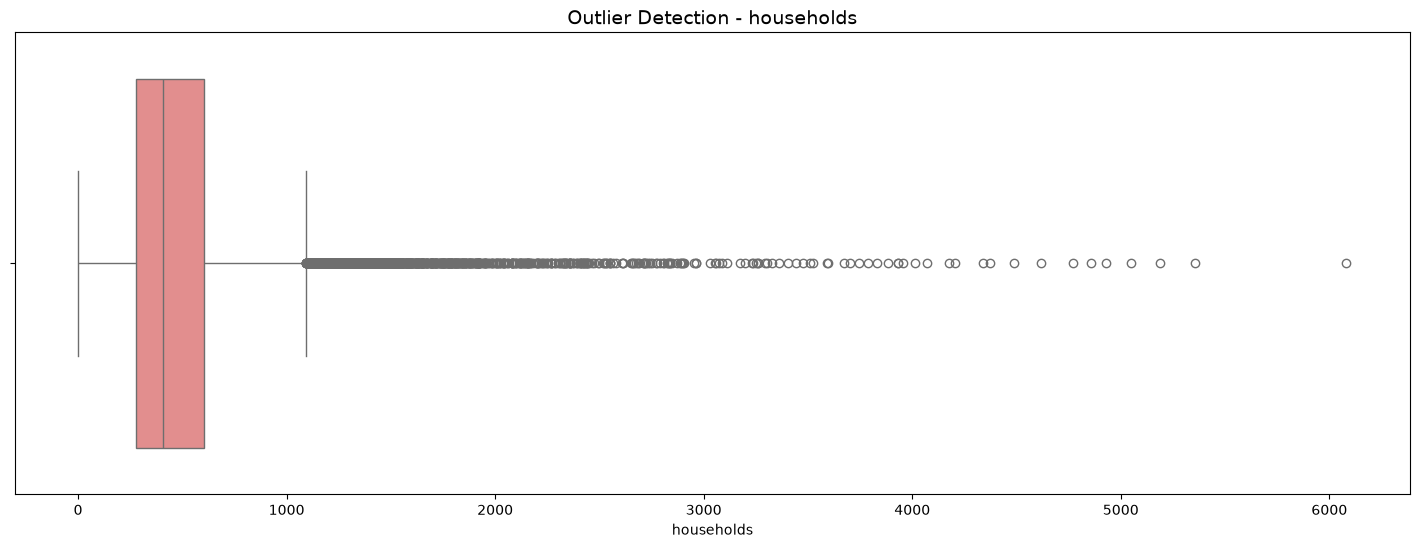

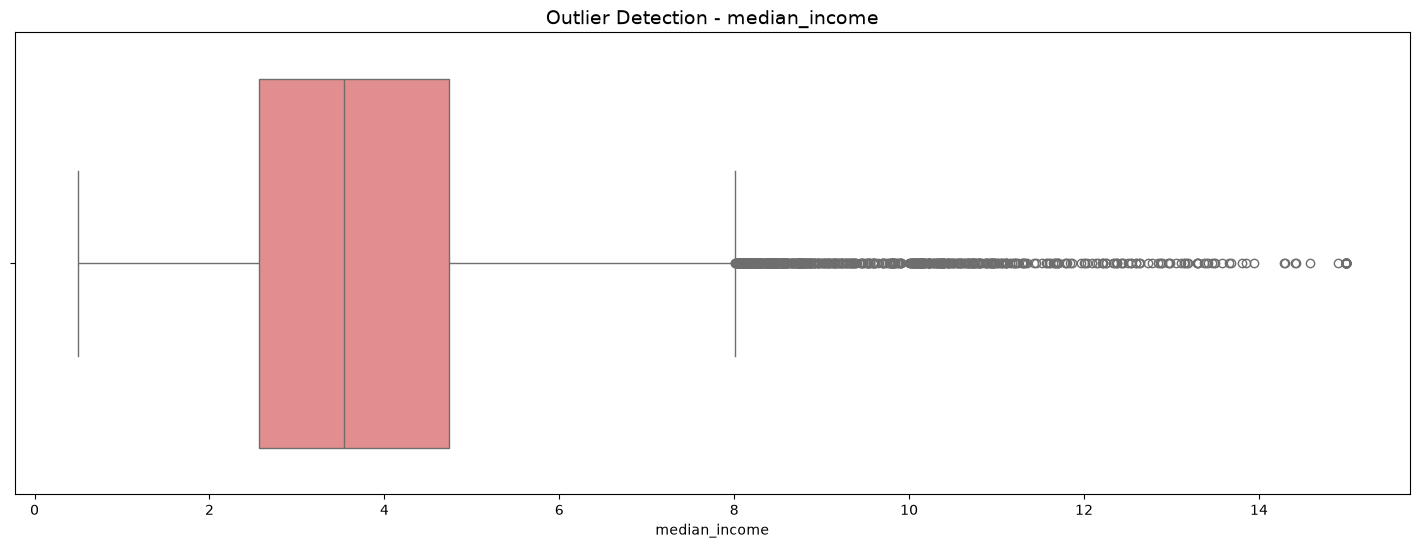

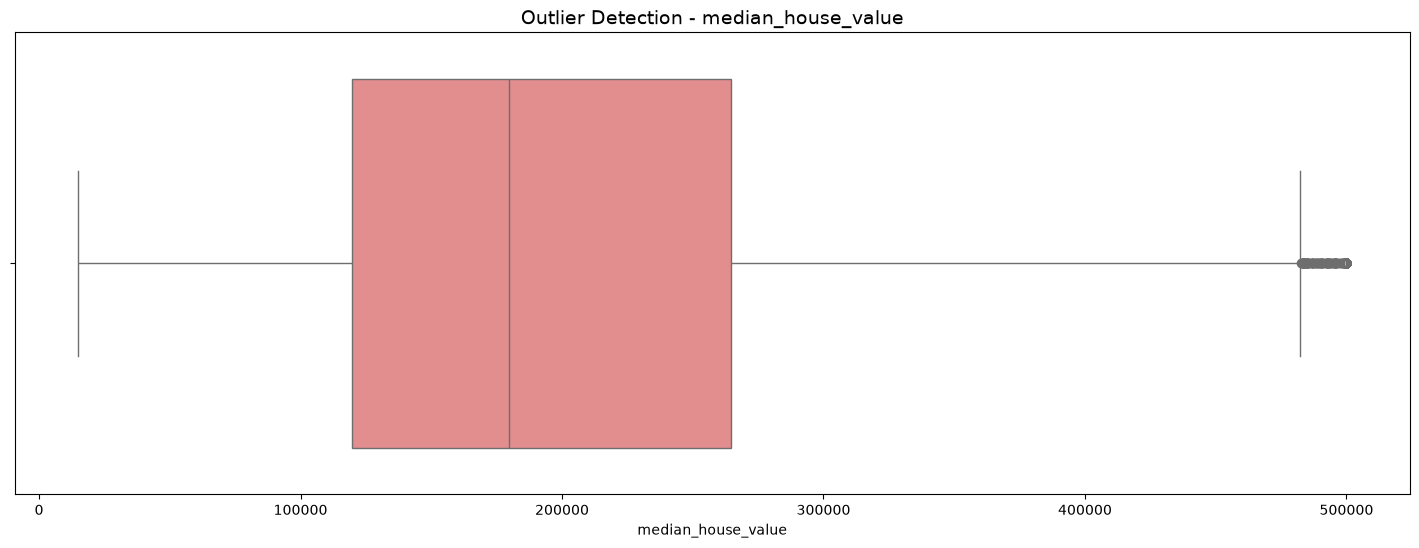

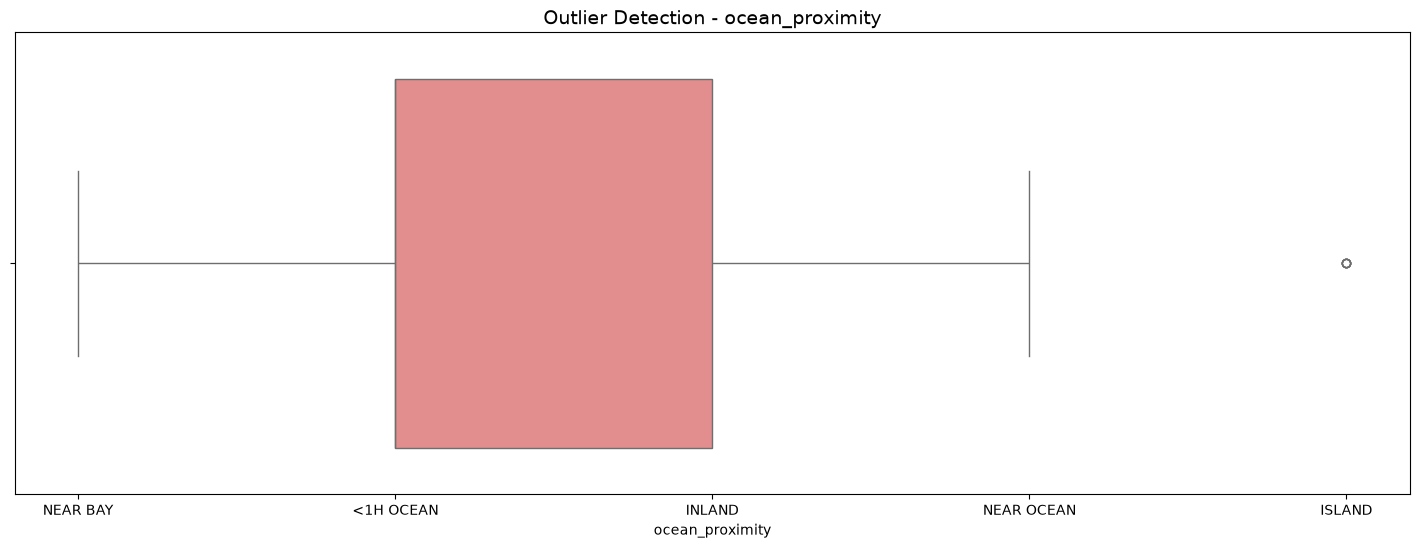

In [15]:

columns = df.columns

for col in columns:
    plt.figure(figsize=(18, 6))

    sns.boxplot(
        x=df[col],
        color='lightcoral'
    )

    plt.title(f'Outlier Detection - {col}', fontsize=14)
    plt.show()



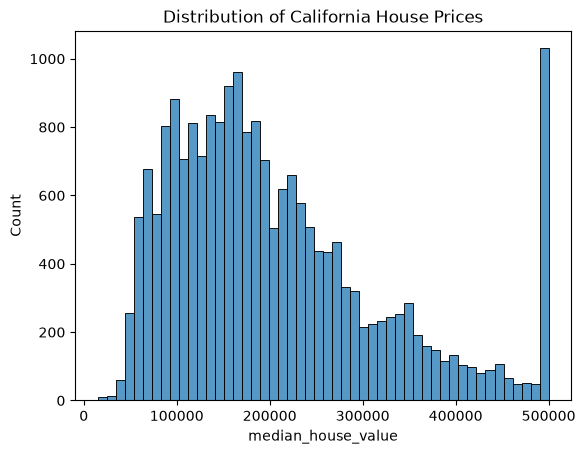

In [16]:
# Plotting the distribution of house prices
sns.histplot(df['median_house_value'], bins=50, kde=False)
plt.title("Distribution of California House Prices")
plt.show()

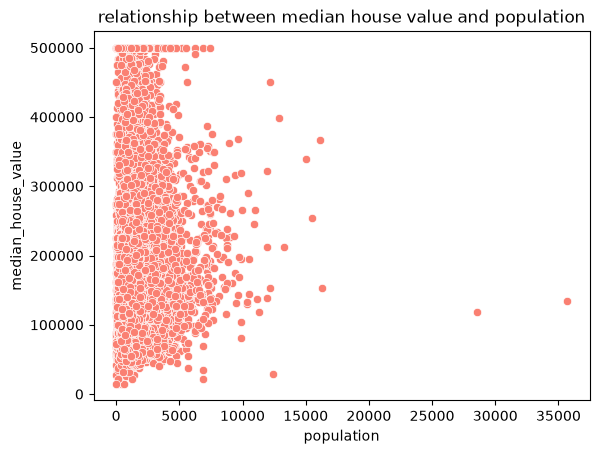

In [17]:
#this was bcz i wanted to see the relationship between two variables hence its called bivariate
sns.scatterplot(x='population', y='median_house_value', color='salmon', data=df)
plt.title('relationship between median house value and population')
plt.show()

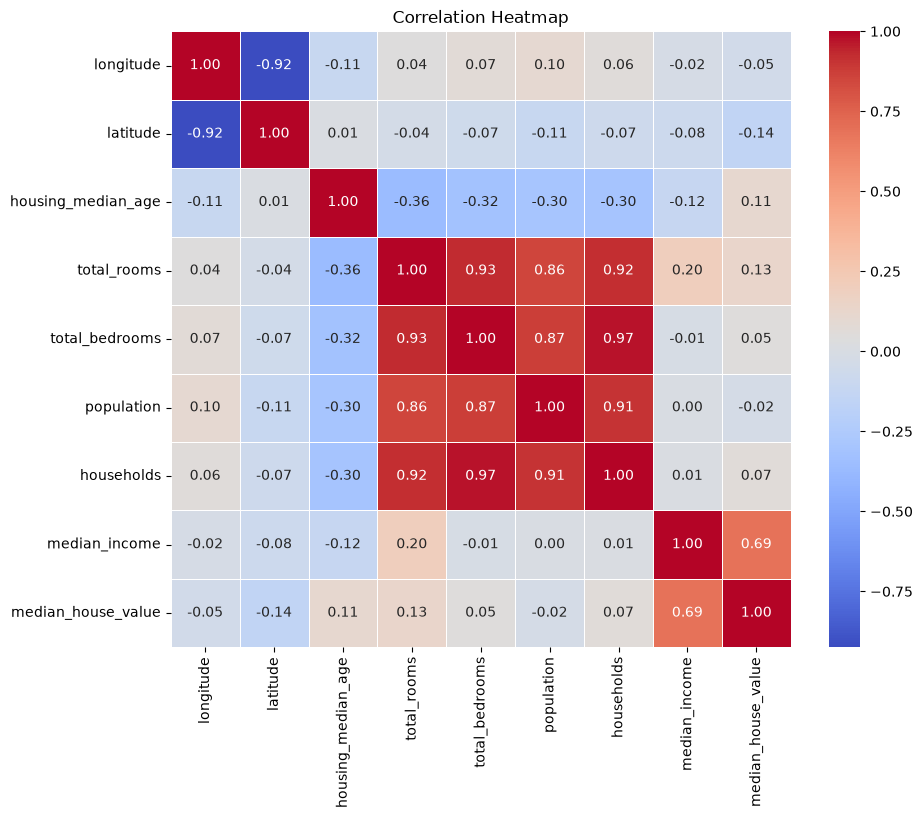

In [18]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()


In [19]:
df[['total_rooms','total_bedrooms','population', 'households', 'median_income',
       'median_house_value']]=np.log1p(df[['total_rooms','total_bedrooms','population', 'households', 'median_income',
       'median_house_value']])

In [20]:
print(df.head())


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0     6.781058        4.867534   
1    -122.22     37.86                21.0     8.867850        7.009409   
2    -122.24     37.85                52.0     7.291656        5.252273   
3    -122.25     37.85                52.0     7.150701        5.463832   
4    -122.25     37.85                52.0     7.395108        5.638355   

   population  households  median_income  median_house_value ocean_proximity  
0    5.777652    4.844187       2.232720           13.022766        NEAR BAY  
1    7.784057    7.037906       2.230165           12.789687        NEAR BAY  
2    6.208590    5.181784       2.111110           12.771673        NEAR BAY  
3    6.326149    5.393628       1.893579           12.740520        NEAR BAY  
4    6.338594    5.560682       1.578195           12.743154        NEAR BAY  


In [21]:
# Encode ocean_proximity

df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=int)

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0     6.781058        4.867534   
1    -122.22     37.86                21.0     8.867850        7.009409   
2    -122.24     37.85                52.0     7.291656        5.252273   
3    -122.25     37.85                52.0     7.150701        5.463832   
4    -122.25     37.85                52.0     7.395108        5.638355   

   population  households  median_income  median_house_value  \
0    5.777652    4.844187       2.232720           13.022766   
1    7.784057    7.037906       2.230165           12.789687   
2    6.208590    5.181784       2.111110           12.771673   
3    6.326149    5.393628       1.893579           12.740520   
4    6.338594    5.560682       1.578195           12.743154   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                       0                       0                         1   
1     

In [22]:
# Features

X = df[['longitude','latitude', 'housing_median_age', 'total_rooms',
       'population', 'households', 'median_income',
'ocean_proximity_INLAND','ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']]

# Target

y = df['median_house_value']

print(X.shape)
print(y.shape)

(20640, 11)
(20640,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 11)
(4128, 11)


In [24]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = root_mean_squared_error(y_test, lr_pred)

lr_r2 = r2_score(y_test, lr_pred)

print("\nLinear Regression")

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)


Linear Regression
MAE: 0.24013341207711503
RMSE: 0.3208879865476441
R2: 0.6827437973419042


In [25]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = root_mean_squared_error(y_test, rf_pred)

rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest")

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)


Random Forest
MAE: 0.1552216003401929
RMSE: 0.23007840883616903
R2: 0.8368996339397708


In [26]:

lr_cv = cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Linear Regression CV Scores")

print(lr_cv)

print("Mean CV R2:", lr_cv.mean())

Linear Regression CV Scores
[0.6112392  0.41929595 0.63031821 0.58904805 0.73400807]
Mean CV R2: 0.5967818961907416


In [27]:
rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Random Forest CV Scores")

print(rf_cv)

print("Mean CV R2:", rf_cv.mean())

Random Forest CV Scores
[0.62231958 0.54574346 0.69356561 0.40044086 0.73558181]
Mean CV R2: 0.5995302625439225


In [28]:
# the scores are pretty good, so now we move on to step 5- improve and validate
# already created features like location, area prices
# grid search cv, helps to choose the beter model and the beter settings for it
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'max_features': ['sqrt', 1.0] # 1.0 means use all features, 'sqrt' helps add variety
}

print("Running GridSearchCV with 5-Fold Cross-Validation... (This may take a moment)")
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2',  # R² score (closer to 1.0 is better)
    n_jobs=-1
)

# Run the grid search on the housing data
grid_search.fit(X, y)

print(f"\nBest Hyperparameters Found: {grid_search.best_params_}")
print(f"Best 5-Fold CV R² Score: {grid_search.best_score_:.4f}\n")


Running GridSearchCV with 5-Fold Cross-Validation... (This may take a moment)

Best Hyperparameters Found: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 50}
Best 5-Fold CV R² Score: 0.6438



In [29]:
#for experiment log
results = pd.DataFrame(grid_search.cv_results_)

# Structure the log cleanly
experiment_log = results[[
    'param_n_estimators', 
    'param_max_depth', 
    'param_max_features', 
    'mean_test_score', 
    'std_test_score'
]]

experiment_log = experiment_log.rename(columns={
    'n_estimators': 'n_estimators',
    'max_depth': 'max_depth',
    'max_features': 'max_features',
    'mean_test_score': '5_Fold_CV_R2',
    'std_test_score': 'CV_R2_Std'
})

In [30]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.015137,0.506674,0.100622,0.076297,10,sqrt,50,"{'max_depth': 10, 'max_features': 'sqrt', 'n_e...",0.639601,0.367068,0.672433,0.578210,0.748957,0.601254,0.129404,6
1,5.174260,0.695209,0.189371,0.102390,10,sqrt,100,"{'max_depth': 10, 'max_features': 'sqrt', 'n_e...",0.642464,0.371442,0.670834,0.589139,0.749005,0.604577,0.127495,3
2,7.207513,0.521809,0.052545,0.006801,10,1.0,50,"{'max_depth': 10, 'max_features': 1.0, 'n_esti...",0.600661,0.410489,0.667904,0.415232,0.731115,0.565080,0.130965,8
3,11.499232,0.740337,0.089814,0.015528,10,1.0,100,"{'max_depth': 10, 'max_features': 1.0, 'n_esti...",0.598165,0.423843,0.670342,0.416109,0.731780,0.568048,0.128109,7
4,2.985780,0.188624,0.071336,0.008413,20,sqrt,50,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",0.678239,0.494611,0.701179,0.586524,0.758337,0.643778,0.092882,1
5,5.447027,0.208013,0.179576,0.068198,20,sqrt,100,"{'max_depth': 20, 'max_features': 'sqrt', 'n_e...",0.662926,0.491221,0.708801,0.590501,0.759666,0.642623,0.093947,2
6,8.127990,0.607159,0.065806,0.002737,20,1.0,50,"{'max_depth': 20, 'max_features': 1.0, 'n_esti...",0.634322,0.533688,0.692156,0.422285,0.731555,0.602801,0.112177,4
7,16.446946,0.246741,0.215578,0.069833,20,1.0,100,"{'max_depth': 20, 'max_features': 1.0, 'n_esti...",0.623722,0.545912,0.694322,0.411474,0.734829,0.602052,0.114965,5
